# Reproducing results on the Sage paper

## Packages

In [1]:
! pip uninstall sage -y
! pip install -e ../

Found existing installation: sage 0.0.1
Uninstalling sage-0.0.1:
  Successfully uninstalled sage-0.0.1
Obtaining file:///home/nnarenraju/Research/sage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sage (pyproject.toml) ... done
  Created wheel for sage: filename=sage-0.0.1-0.editable-py3-none-any.whl size=15086 sha256=033563ca37c75e5419994d65c6ca1eae4f2c35cb8ed500ec27edccff8fdd3cce
  Stored in directory: /tmp/pip-ephem-wheel-cache-qy5h84oi/wheels/9b/47/cf/bfd99e705866b88810d9db84a85969530a2783f51228948a36
Successfully built sage


In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import os
import h5py
import time
import math
import json
import torch
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

import lal
import lalsimulation as lalsim

In [3]:
def time_it(func, args, ntries=1000):
    start = time.time()
    for _ in range(ntries):
        func(args)
    time_taken = (time.time() - start)/ntries
    return time_taken

In [4]:
from pycbc import DYN_RANGE_FAC

In [5]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.0
    noise_low_frequency_cutoff = 15.0

In [6]:
config = cfg()
data_config = data_cfg()

## Get segments/timeline for downloading real noise 

In [ ]:
from sage.data.primer import TimelineQuery, get_all_detnames, get_all_runnames

In [ ]:
print(get_all_detnames())
print(get_all_runnames())

{'K1', 'G1', 'H2', 'L1', 'H1', 'V1'}
['O1', 'O2', 'O3GK', 'O3a', 'O3b', 'O4a', 'O4b1Disc', 'O4b2Disc', 'O4b3Disc', 'S5', 'S6']


In [ ]:
tq = TimelineQuery(detector=["H1", "L1", "V1"], 
                   observing_run=["O3a",],
                   start = 1238166018,
                   end = 1238176018,
                   auto_clean_empty_timelines=True)
                                
tq.download_segments()

2026-02-11 15:37:44 | INFO     | sage.data.primer.get_segments:287 | Getting all segments between 1238166018-1238176018 for all detectors in the correct observing run


In [ ]:
tq.prune_segments(
    rm_short_segments = True,
    rm_min_duration = 22.0,
    rm_allevents = True,
    rm_window_length = 30,
)

2026-02-11 15:37:45 | INFO     | sage.data.primer.get_segments:526 | Removing all events (obtained from GWOSC) from segments
2026-02-11 15:37:45 | INFO     | sage.data.primer.get_segments:527 | [event_gps - rm_length, event_gps + rm_length] will be removed
2026-02-11 15:37:47 | INFO     | sage.data.primer.get_segments:550 | Removing segments below the min duration of 22.0


In [ ]:
tq.timeline

array([('H1', 'H1_DATA', 1.23816602e+09, 1.23817602e+09, 'O3a', array([[1.23816602e+09, 1.23817055e+09],
              [1.23817095e+09, 1.23817293e+09],
              [1.23817299e+09, 1.23817602e+09]]))                                                       ,
       ('L1', 'L1_DATA', 1.23816602e+09, 1.23817602e+09, 'O3a', array([[1.23816602e+09, 1.23817029e+09],
              [1.23817543e+09, 1.23817602e+09]]))                                                       ,
       ('V1', 'V1_DATA', 1.23816602e+09, 1.23817602e+09, 'O3a', array([[1.23816602e+09, 1.23817602e+09]]))],
      dtype=[('detector', '<U2'), ('flag', '<U10'), ('start_time', '<f8'), ('end_time', '<f8'), ('observing_run', '<U10'), ('segments', 'O')])

In [ ]:
# We trim the edges after downsamping; so trim length must be accounted for
# However it can't be arbitrary since we won't get a proper integer removal of samples
# So we get the nearest trim length above a threshold that will give us an integer for a given sample rate
buffer = math.ceil(0.2 * data_config.sample_rate)/data_config.sample_rate

In [ ]:
tq.split_into_mini_segments(
    mini_segment_length=512.0 + (buffer * 2.),
    minimum_segment_duration=16.0,
)

In [ ]:
tq.timeline

array([('H1', 'H1_DATA', 1.23816602e+09, 1.23817602e+09, 'O3a', array([[1.23816602e+09, 1.23816653e+09],
              [1.23816651e+09, 1.23816703e+09],
              [1.23816701e+09, 1.23816752e+09],
              [1.23816751e+09, 1.23816802e+09],
              [1.23816800e+09, 1.23816852e+09],
              [1.23816850e+09, 1.23816901e+09],
              [1.23816900e+09, 1.23816951e+09],
              [1.23816949e+09, 1.23817001e+09],
              [1.23816999e+09, 1.23817050e+09],
              [1.23817049e+09, 1.23817055e+09],
              [1.23817095e+09, 1.23817147e+09],
              [1.23817145e+09, 1.23817196e+09],
              [1.23817195e+09, 1.23817246e+09],
              [1.23817244e+09, 1.23817293e+09],
              [1.23817299e+09, 1.23817350e+09],
              [1.23817348e+09, 1.23817400e+09],
              [1.23817398e+09, 1.23817449e+09],
              [1.23817448e+09, 1.23817499e+09],
              [1.23817497e+09, 1.23817549e+09],
              [1.23817547e+09, 

In [ ]:
tq.sanity_check_mini_segments(
    mini_segment_length=512.0 + (buffer * 2.),
    minimum_segment_duration=16.0,
    verbose=True,
)

## Download segments from GWOSC

In [ ]:
from sage.data.primer import DataReleaseDownloader

In [ ]:
drd = DataReleaseDownloader(
    segments_metadata=tq.timeline,
    save_parent_dir="./",
    noise_low_freq_cutoff = 15.0,
    minimum_segment_duration = 22.0,
    corrupt_trim_length = buffer,
    max_download_retries = 15,
    retry_delay = 0.5,
    num_workers = 4,
    make_monolithic_file = True,
    sample_rate = data_config.sample_rate,
    save_bin=True,
)

drd.download()

2026-02-11 15:37:48 | INFO     | sage.data.primer.get_data_release:531 | Downloading segments from H1 for O3a


Validating segments in H1-O3a: 100%|██████████| 42/42 [00:40<00:00,  1.05it/s]

2026-02-11 15:38:28 | INFO     | sage.data.primer.get_data_release:541 | H1 O3a: Available = 9816.58740234375, Valid = 9816.58740234375.
2026-02-11 15:38:28 | WARNING  | sage.data.primer.get_data_release:545 | Min duration & data availability might reduce valid duration.
2026-02-11 15:38:28 | INFO     | sage.data.primer.get_data_release:382 | Fetching GWOSC data for detector H1 (O3a) using 4 worker(s)



MP-DET_SCIENCE_DATA GWOSC: 100%|██████████| 21/21 [00:13<00:00,  1.58it/s]


2026-02-11 15:38:42 | INFO     | sage.data.primer.get_data_release:531 | Downloading segments from L1 for O3a


...


MP-DET_SCIENCE_DATA GWOSC: 100%|██████████| 11/11 [00:06<00:00,  1.81it/s]


2026-02-11 15:39:03 | INFO     | sage.data.primer.get_data_release:531 | Downloading segments from V1 for O3a


Validating segments in V1-O3a: 100%|██████████| 42/42 [00:36<00:00,  1.14it/s]

2026-02-11 15:39:40 | INFO     | sage.data.primer.get_data_release:541 | V1 O3a: Available = 10311.5869140625, Valid = 10311.5869140625.
2026-02-11 15:39:40 | WARNING  | sage.data.primer.get_data_release:545 | Min duration & data availability might reduce valid duration.
2026-02-11 15:39:40 | INFO     | sage.data.primer.get_data_release:382 | Fetching GWOSC data for detector V1 (O3a) using 4 worker(s)



MP-DET_SCIENCE_DATA GWOSC: 100%|██████████| 21/21 [00:13<00:00,  1.59it/s]


In [ ]:
foo = h5py.File('./data_release/data_L1_O3a.h5', 'r')
print(list(foo.keys()))

In [ ]:
foo['segments'].keys()

<KeysViewHDF5 ['00000', '00001']>

In [ ]:
# TODO: Find out why this is slightly smaller than expected
num = np.array(foo['segments/00000']).shape[0] + np.array(foo['segments/00001']).shape[0]
print((num+0)/2048.)

4855.19921875


In [ ]:
foo['segments/00000'].attrs.keys()

<KeysViewHDF5 ['detector', 'gps_end', 'gps_start', 'noise_low_freq_cutoff', 'nsamples', 'old_sample_rate', 'run', 'sample_rate', 'trim']>

## Generate batches of noise samples

In [ ]:
from sage.data.noise import MemmapNoiseSampler
from pycbc import DYN_RANGE_FAC

In [ ]:
with open("./data_release/data_L1_O3a.bin", "rb") as f:
    raw = f.read()

# If you change this to float64, you should see garbage
# HDF5 handles this implicitly; raw binary does not
arr = np.frombuffer(raw, dtype=np.float32)

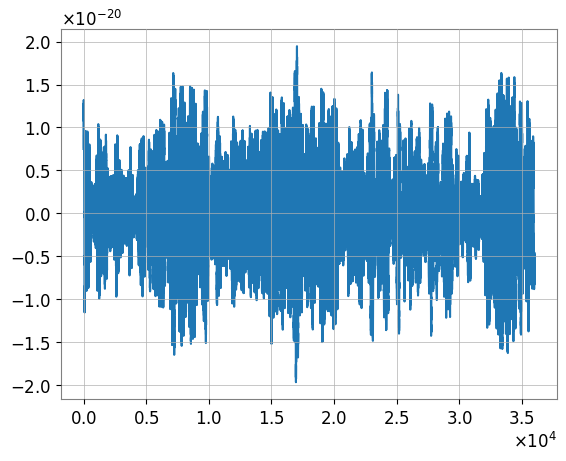

In [ ]:
plt.plot(arr[10_000:46_000] / DYN_RANGE_FAC)

In [ ]:
foo = h5py.File('./data_release/data_L1_O3a.h5', 'r')
check_hdf5_data = np.array(foo['segments/00000'])

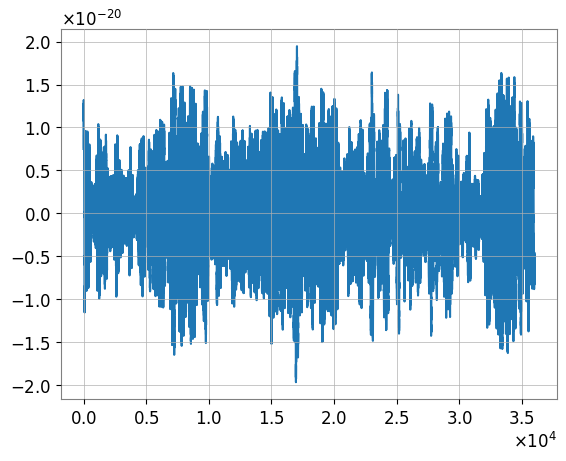

In [ ]:
plt.plot(check_hdf5_data[10_000:46_000] / DYN_RANGE_FAC)

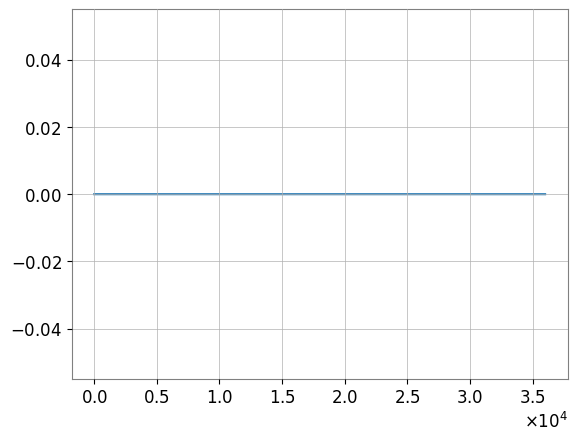

In [ ]:
# If we do HDF5 in float64 for example, we should see a residual of the order 1e-27 to 1e-28
# With the same handling if you see a residual of absolute 0, then we are bit identical
HDF5_data = check_hdf5_data[10_000:46_000] / DYN_RANGE_FAC
BIN_data = arr[10_000:46_000] / DYN_RANGE_FAC
plt.plot(HDF5_data - BIN_data)

In [ ]:
files = [
    "./data_release/data_H1_O3a.bin",
    "./data_release/data_L1_O3a.bin",
    "./data_release/data_V1_O3a.bin",
]

seq_len = 20 * 2048
batch_size = 64
sampler = MemmapNoiseSampler(files, seq_len=seq_len, device="cuda:0", batch_size=64, prefetch=3)

In [ ]:
## Mock Training loop
# Warm up
for _ in range(100):
    _ = sampler.sample_batch(batch_size)

# Measure
t0 = time.perf_counter()
for _ in range(1000):
    batch = sampler.sample_batch(batch_size)
t1 = time.perf_counter()

print("Avg batch latency:", (t1 - t0) / 1000)

sampler.shutdown()

Avg batch latency: 0.009968676797114313


## Make noise PSDs and fiducial detector PSD

In [7]:
from sage.data.primer import EstimatePSD
from sage.dsp.welch import TorchWelch
from sage.data.primer import NoBlackout, HardRatioBlackout
from sage.data.noise import MemmapSingleNoiseSampler
from sage.data.psd import smoothing

In [22]:
detector = "V1"

In [23]:
torch_welch = TorchWelch(
    delta_t=1/2048,
    seg_len=int(2048.*4),
    seg_stride=int(2048.*2),
    avg_method="median",
)

psd_smoothener = smoothing.LogSplineSmoothing(
    smooth_factor=None, 
    noise_low_frequency_cutoff=data_config.noise_low_frequency_cutoff,
)

epsd = EstimatePSD(
    
    # Detector
    detector=detector,

    # Inverse spectrum truncation
    apply_inverse_spectrum_truncation = False,
    max_filter_len = int(round(2048. * 2)),
    low_frequency_cutoff = 15.0,
    trunc_method = "hann",

    # PSD estimation method
    psd_method = torch_welch,
    num_samples = 20,
    store_psds_as_bin = True,

    # Fiducial PSD parameters
    blackout_policy = NoBlackout(),

    # Interpolation
    interpolate_psd=True,
    training_sample_length=int(2048. * 16),

    # PSD Smoothening
    psd_smoothener = psd_smoothener,

    # Kwargs from Sage config
    cfg = cfg(), 
    data_cfg = data_cfg(),
)

In [24]:
# This is used for whitening with the exact segment PSD before recolouring
epsd.estimate_segment_psds(noise_segments_file=f"./data_release/data_{detector}_O3a.bin")

Computing PSDs per segment: 100%|██████████| 21/21 [00:03<00:00,  6.62it/s]


In [25]:
# This is used to make the recolouring PSDs and fiducial detector PSD
noise_sampler = MemmapSingleNoiseSampler(f"./data_release/data_{detector}_O3a.bin")

In [26]:
# The following is  all you need to sample a noise segment of arbitrary length from the bin file
# The sampler should automagically choose segments proportional to the segment duration
# So sampling is as uniform as possible
noise_sampler(40960)

# This should  be relatively quick compared to HDF5 I/O
# But we will rely on the batch sampler for production runs for more efficiency

array([ 1.3540838e-19,  3.4652656e-19, -1.0388223e-21, ...,
        2.3867648e-19,  6.0634665e-20, -2.1300344e-19],
      shape=(40960,), dtype=float32)

In [27]:
# We can also make it return a torch tensor if downstream ops rely on torch
# Specify tensor_dtype if needed; use .to() if you want to put it on a CUDA device
noise_sampler = MemmapSingleNoiseSampler(f"./data_release/data_{detector}_O3a.bin", return_tensor=True)
noise_sampler(40960)

tensor([ 3.7319e-19, -1.3853e-19, -4.1217e-19,  ...,  2.9141e-20,
        -3.4070e-19, -1.4413e-19])

In [28]:
# With this we make num_samples random PSDs from the given data
# We use this for recolouring augmentation
# We also do blackout and aggregate the PSDs to produce the fiducial PSD
epsd.estimate_raw_psds(noise_sampler=noise_sampler, duration=int(round(2048. * 512)))

Estimating PSDs for V1: 100%|██████████| 20/20 [00:02<00:00,  7.63it/s]


## Spline smoothing of local PSD

In [11]:
psds_all = []

for det in ['H1', 'L1']:
    psd_dir = Path(data_config.data_dir) / "recolour_psds"
    bin_path = psd_dir / f"raw_{det}_psds.bin"
    meta_path = psd_dir / f"raw_{det}_psds.json"

    with open(meta_path, "r") as f:
        meta = json.load(f)

    n_psd = meta["num_psds"]
    n_freq = meta["num_freq_bins"]  # should == F

    psds = np.fromfile(bin_path, dtype=np.float32).reshape(n_psd, n_freq)
    psds_all.append(psds)

recolour_psds = torch.from_numpy(np.stack(psds_all, axis=0)).float()

In [9]:
for det in ['H1']:
    psd_dir = Path(data_config.data_dir) / "segment_psds"
    bin_path = psd_dir / f"data_{det}_O3a_psds.bin"
    meta_path = psd_dir / f"data_{det}_O3a_psds_segments.json"

    with open(meta_path, "r") as f:
        meta = json.load(f)
    
    raw = np.fromfile(bin_path, dtype=np.float32)

    psds = []
    cursor = 0
    for m in meta:
        n = m["psd_len"]  # should already be == F
        psds.append(raw[cursor : cursor + n])
        cursor += n

    segment_psds = np.stack(psds, axis=0)  # (N_seg, F)

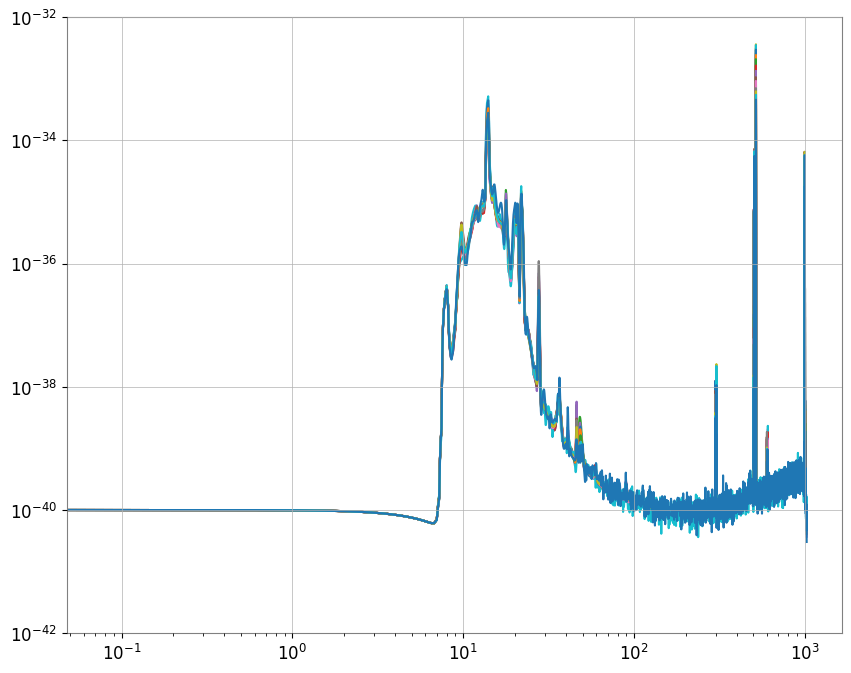

In [12]:
freqs = np.arange(n_freq) * (1./13.0)

plt.figure(figsize=(10, 8))
for psd in segment_psds:
    plt.loglog(freqs, psd)
    #plt.xlim(15.0, 1024.0)
    plt.ylim(1e-42, 1e-32)

plt.show()

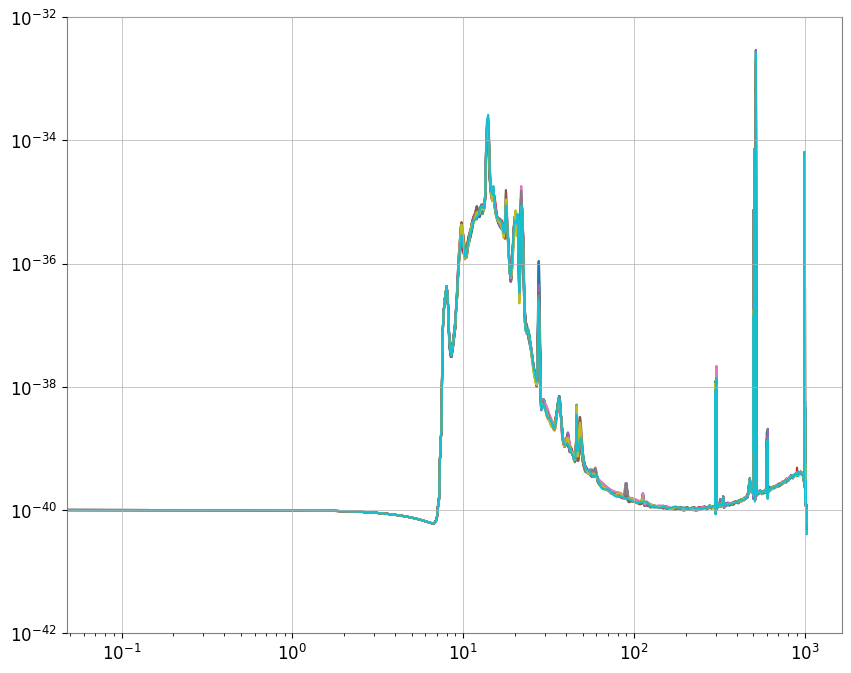

In [54]:
freqs = np.arange(n_freq) * (1./13.0)

plt.figure(figsize=(10, 8))
for psd in recolour_psds[0, :]:
    plt.loglog(freqs, psd)
    #plt.xlim(15.0, 1024.0)
    plt.ylim(1e-42, 1e-32)

plt.show()

In [ ]:
freqs.shape, recolour_psds[0,0].shape

((16385,), torch.Size([16385]))

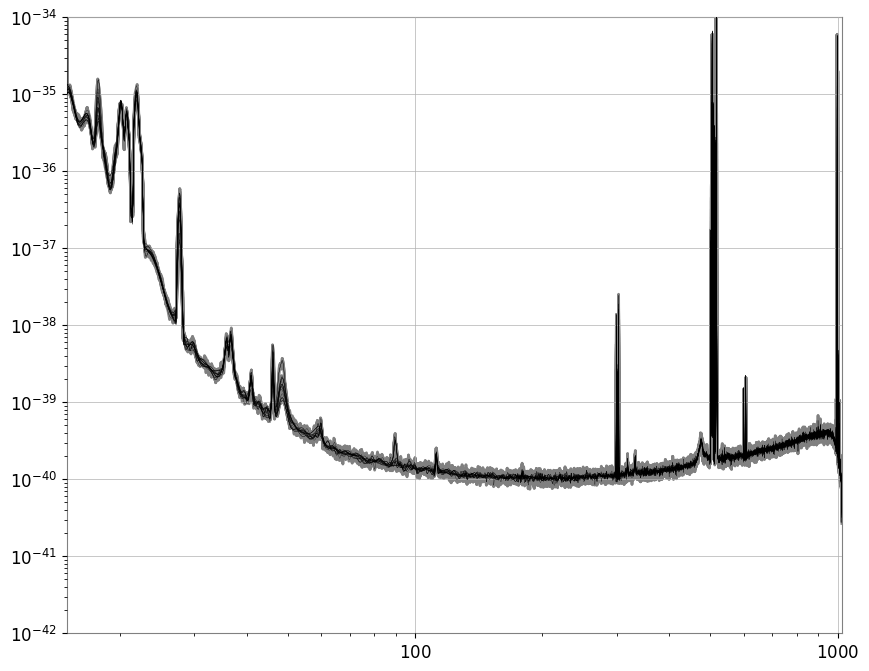

In [ ]:
line_regions = [(50, 70), (280, 350), (450, 650)]
smoothener = smoothing.LogSplineSmoothing(smooth_factor=0.005*len(freqs), noise_low_frequency_cutoff=data_config.noise_low_frequency_cutoff)
plt.figure(figsize=(10, 8))
for psd in recolour_psds[0, :]:
    psd_safe = psd.detach().cpu().numpy().copy()
    smoothed = smoothener.smooth(freqs, psd_safe)
    plt.loglog(freqs, smoothed, linewidth=0.2, c='k', zorder=999)
    plt.loglog(freqs, psd, linewidth=2, c='gray', alpha=1)
    plt.xlim(15.0, 1024.0)
    plt.ylim(1e-42, 1e-34)
plt.show()

## Recolouring noise batches and returning FD noise

In [7]:
from sage.data.noise import MemmapNoiseSampler
from sage.data.noise import recolour

In [8]:
files = [
    "./data_release/data_H1_O3a.bin",
    "./data_release/data_L1_O3a.bin",
]

seq_len = 16 * 2048
batch_size = 64

postprocess = recolour.RecolourPostprocess(
    data_dir=data_cfg.data_dir,
    detectors=["H1", "L1"],
    seq_len=seq_len,
    sample_rate=data_cfg.sample_rate,
    p_recolour=0.37,
    device="cuda:0",
)

sampler = MemmapNoiseSampler(
    files, 
    seq_len=seq_len, 
    pad_len=0.0,
    device="cuda:0", 
    batch_size=64, 
    prefetch=3,
    postprocess_fn=postprocess,
    # Kwargs from Sage config
    cfg = cfg(), 
    data_cfg = data_cfg(),
)

In [9]:
noise_batch = sampler.sample_batch(batch_size)
print(noise_batch.size())

torch.Size([64, 2, 16385])


In [10]:
## Mock Training loop 
# Avg batch latency: 0.008375571766002395 (if we stored PSDs on VRAM)
# Avg batch latency: 0.01096726394299185 (if we stored PSDs on RAM)
# The CPU speed is good enough; we can't place all precomputed PSDs on VRAM anyway

# Warm up
for _ in range(100):
    _ = sampler.sample_batch(batch_size)

# Measure
t0 = time.perf_counter()
for _ in range(1000):
    batch = sampler.sample_batch(batch_size)
t1 = time.perf_counter()

print("Avg batch latency:", (t1 - t0) / 1000)

sampler.shutdown()

Avg batch latency: 0.011843834838015028


## Sage fully vectorised signal generation on torch.compile (IMRPhenomD)

In [34]:
from sage.data.waveform import IMRPhenomD as imr
from sage.data.waveform import project

In [35]:
IMRphenom = 'IMRPhenomD'

m1_msun = 30.0 # In solar masses
m2_msun = 30.0
chi1 = 0.99
chi2 = 0.99
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.5 # Inclination Angle
polarization_angle = 0.0 # Polarization angle
ra = 0.12
dec = 0.2

params = torch.tensor(
    [m1_msun, m2_msun, chi1, chi2, dist_mpc, tc, phic, inclination, polarization_angle, ra, dec],
    device='cuda:0',
    dtype=torch.float64
)

batch_size = 500
params_batch = params.unsqueeze(0).expand(batch_size, -1).clone()  # shape: (10, 9)

In [36]:
# Generate the frequency grid
f_l = 20.
f_u = 2048.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f = f.unsqueeze(0).expand(batch_size, -1).clone()

f_ref = torch.tensor(f_l, device='cuda:0', dtype=torch.float64)
f_ref = f_ref.unsqueeze(0).expand(batch_size, -1).clone()

In [37]:
phd = imr.IMRPhenomD(f, f_ref)

In [38]:
## With compile we take 0.0005 seconds for 500 waveforms (20 seconds at 2048 Hz)
start = time.time()
hp_sage, hc_sage = phd(params_batch, reproduce_lal=True)
print(f"Time taken to produce 500 IMRPhenomD waveforms = {time.time() - start}")

Time taken to produce 500 IMRPhenomD waveforms = 10.416567325592041


Requested tc = 0.0 s, observed tc = 19.995 s


(81850.0, 81950.0)

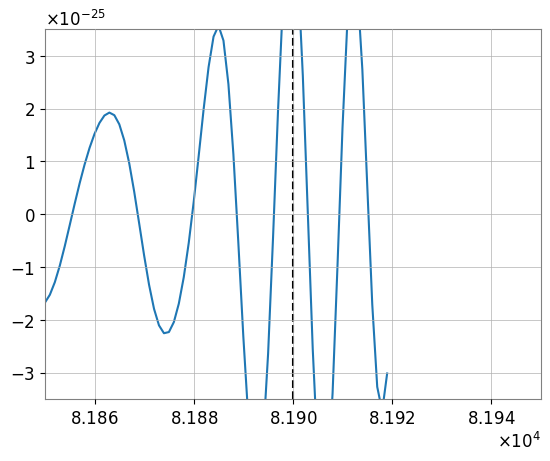

In [39]:
t_peak = torch.argmax(torch.abs(torch.fft.irfft(hp_sage[0])), dim=-1)
t_peak = t_peak.detach().cpu().numpy()
print(f"Requested tc = {params[5]} s, observed tc = {round(t_peak/4096., 3)} s")

plt.plot(np.fft.irfft(hp_sage[0].detach().cpu().numpy()))
plt.vlines(t_peak, -3.5e-25, 3.5e-25, linestyle="--", color='k')
plt.ylim(-3.5e-25, 3.5e-25)
plt.xlim(t_peak-50, t_peak+50)

In [ ]:
## With compile we take 0.000325 seconds PER waveform 20 seconds at 2048 Hz (1000 tries over batches of 500)
out = time_it(phd, (params_batch), ntries=1000)
print('Time taken to produce 1 waveform with PyTorch (without compile) = {} seconds'.format(round(out/500.,10)))

IT'S ALIVE!!!

With torch.compile we take about 0.00032 seconds per waveform. So about 3124 waveforms per second. Each waveform is 20 seconds long at a sampling frequency of 2048 Hz. This is pretty good and should be more than fast enough for training Sage.

In [ ]:
pwave = project.ProjectWave(detector_names = ('H1', 'L1', 'V1'), device='cuda:0')

In [ ]:
f_l = 0.
f_u = 2048.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)

In [ ]:
start = time.time()
out = pwave.constant_project(hp_sage, hc_sage, f, ra=params_batch[:,-2], dec=params_batch[:,-1], polarization=params_batch[:,-3])
print(time.time()-start)

0.0012238025665283203


### Comparing fully vectorised Sage to LAL for IMRPhenomD

In [ ]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomD")
m1_msun = 30.0 # In solar masses
m2_msun = 30.0
chi1 = 0.99
chi2 = 0.99
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.5 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 1.0/20.0
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0., 0., chi1,
                                            0., 0., chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


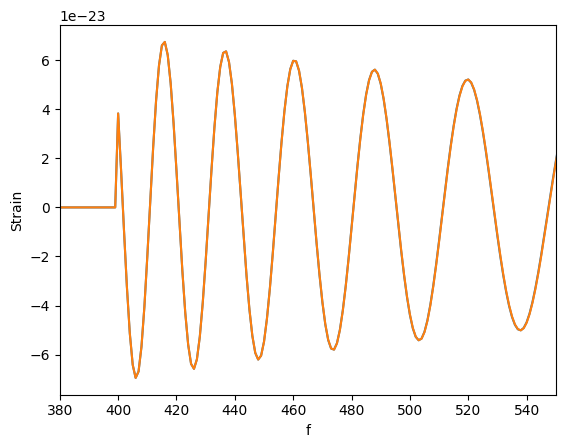

In [ ]:
plt.plot(hp_lalsim)
plt.plot(hp_sage[0].detach().cpu().numpy())
plt.xlim(380, 550)
plt.xlabel('f')
plt.ylabel('Strain')
plt.show()

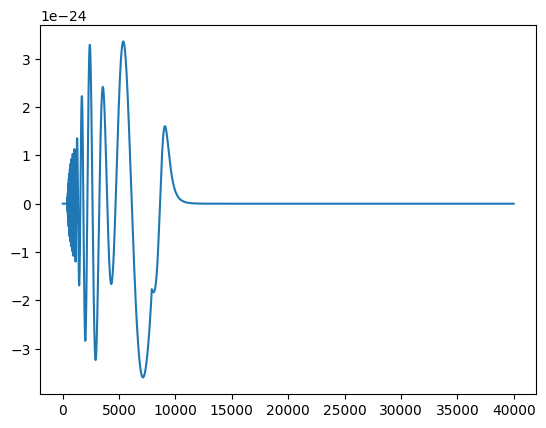

In [ ]:
plt.plot(hc_sage[0].detach().cpu().numpy()[:40_000] - hc_lalsim[:40_000])

LAL might have extra zeroes padded to get the length to the next power of two. So a requested length of 40961 (20 seconds at 2048 Hz + 1) will produce 65537 (this is 2**16 + 1). The extra +1 is due to accounting for the DC componenet of 0*df.

## Sage fully vectorised signal generation on torch.compile (IMRPhenomPv2)

In [10]:
from sage.data.waveform import IMRPhenomPv2 as pv2
from sage.data.waveform import project

In [11]:
IMRphenom = 'IMRPhenomPv2'

m1 = 20.0
m2 = 19.0
s1x = 0.5
s1y = 0.5
s1z = 0.5
s2x = 0.5
s2y = 0.5
s2z = 0.5
dist_mpc = 440.0
tc = 0.0
phic = 0.5
inclination = 0.2
polarization_angle = 0
ra = 0.12
dec = 0.2

params = torch.tensor(
    [m1, m2, s1x, s1y, s1z, s2x, s2y, s2z, dist_mpc, tc, phic, inclination, polarization_angle, ra, dec],
    device='cuda:0',
    dtype=torch.float64
)

batch_size = 64
params_batch = params.unsqueeze(0).expand(batch_size, -1).clone()

In [12]:
# Generate the frequency grid
f_l = 20.
f_u = 1024.
del_f = 1./16.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f = f.unsqueeze(0).expand(batch_size, -1).clone()

f_ref = torch.tensor(f_l, device='cuda:0', dtype=torch.float64)
f_ref = f_ref.unsqueeze(0).expand(batch_size, -1).clone()

In [13]:
f.shape

torch.Size([64, 16065])

In [14]:
php = pv2.IMRPhenomPv2(f, f_ref)

In [15]:
start = time.time()
hp_sage, hc_sage = php(params_batch)
print(f'Time taken for a batch of Pv2 waveforms = {time.time()-start} seconds')

Time taken for a batch of Pv2 waveforms = 8.098398208618164 seconds


In [16]:
pwave = project.ProjectWave(detector_names = ('H1', 'L1'), device='cuda:0')

f_l = 0.
f_u = 1024.
del_f = 1./16.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)

In [17]:
start = time.time()
signal_batch = pwave.constant_project(hp_sage, hc_sage, f, ra=params_batch[:,-2], dec=params_batch[:,-1], polarization=params_batch[:,-3])
print(time.time()-start)

0.027497053146362305


In [18]:
signal_batch.shape

torch.Size([64, 2, 16385])

/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


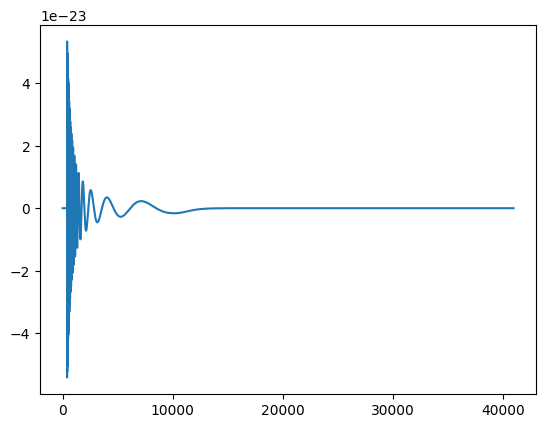

In [ ]:
plt.plot(hp_sage[0].detach().cpu().numpy())

### Comparing fully vectorised Sage to LAL for IMRPhenomPv2

In [ ]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomPv2")
m1_msun = 20.0 # In solar masses
m2_msun = 19.0
chi1 = 0.5
chi2 = 0.5
tc = 0.0 # Time of coalescence in seconds
phic = 0.5
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.2 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 1./20.
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0.5, 0.5, chi1,
                                            0.5, 0.5, chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

(350.0, 1000.0)

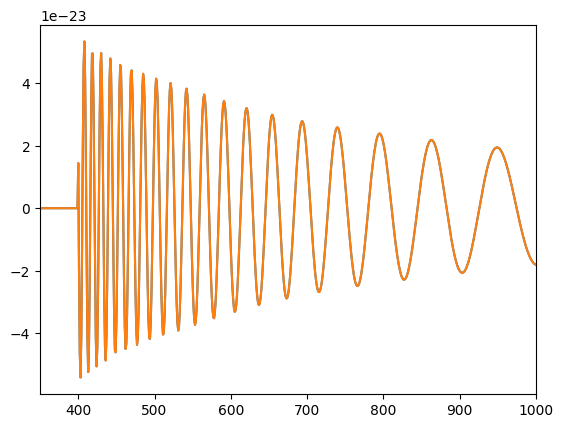

In [ ]:
plt.plot(hp_sage[0].detach().cpu().numpy())
plt.plot(hp_lalsim)
plt.xlim(350, 1000)

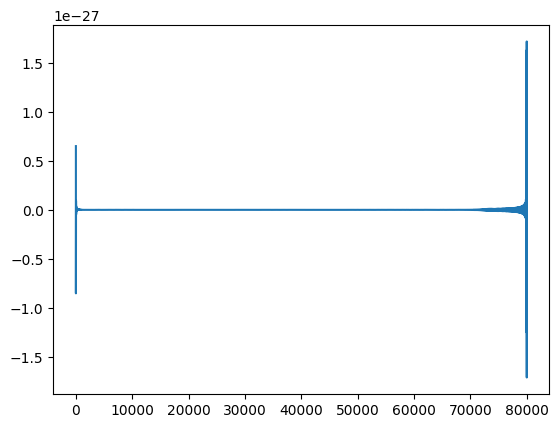

In [ ]:
plt.plot(np.fft.irfft(hp_sage[0].detach().cpu().numpy()[:40_000]) - np.fft.irfft(hp_lalsim[:40_000]))

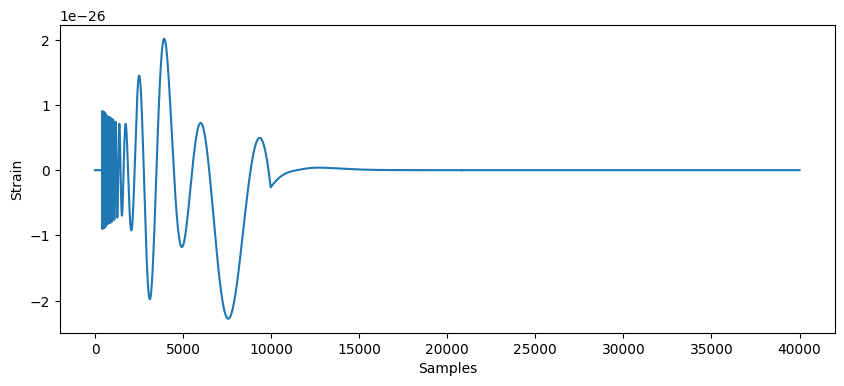

In [ ]:
plt.figure(figsize=(10.0, 4.0))
plt.plot(hp_lalsim[:40_000] - hp_sage[0].detach().cpu().numpy()[:40_000])
plt.xlabel('Samples')
plt.ylabel('Strain')
plt.show()

## Whitening the signal + noise sample

In [19]:
from sage.dsp.whiten import FiducialWhitening

In [20]:
noisy_signal = signal_batch + noise_batch

In [21]:
psds_all = []

for det in ['H1', 'L1']:
    psd_dir = Path(config.export_dir) / "fiducial_psds"
    bin_path = psd_dir / f"fiducial_{det}_psd.bin"
    meta_path = psd_dir / f"fiducial_{det}_psd.json"

    with open(meta_path, "r") as f:
        meta = json.load(f)

    psds = np.fromfile(bin_path, dtype=np.float32)
    psds_all.append(psds)

fiducial_psds = torch.from_numpy(np.stack(psds_all, axis=0)).float().to(device='cuda:0')

In [22]:
whitener = FiducialWhitening(fiducial_psds, seq_len=int(2048.0 * 16), sample_rate=2048.0, device='cuda:0')

In [23]:
whitener.whiten(noisy_signal)

tensor([[[ 0.0171,  0.0174,  0.4819,  ...,  0.4704,  0.0146, -0.1496],
         [ 0.1864,  0.9461,  0.8726,  ..., -0.0662,  0.1842, -0.2622]],

        [[-0.7049, -0.9021,  0.0534,  ...,  0.3574, -0.4514, -0.7738],
         [ 1.3375,  0.3279, -0.3214,  ...,  0.7663, -0.0850, -0.5125]],

        [[ 0.6582,  0.8619, -0.9240,  ...,  0.1890,  0.1362, -0.4909],
         [ 0.9992,  0.5042, -0.4024,  ..., -0.4157,  0.3962,  0.3184]],

        ...,

        [[-0.7231,  0.5517,  1.0798,  ...,  0.3063, -0.4803, -0.3976],
         [-0.5855, -0.0321, -0.7107,  ...,  0.0049,  0.4526, -0.8658]],

        [[-0.5194, -0.3393, -0.2399,  ..., -1.1691, -0.1606, -0.1940],
         [ 0.3474, -0.3762,  1.1467,  ...,  0.2863, -0.1426,  0.0827]],

        [[-1.2629,  0.7529, -0.6709,  ...,  0.2537, -0.8074,  0.5782],
         [-1.0829,  0.3740,  0.3580,  ...,  0.2728, -0.7121, -0.2828]]],
       device='cuda:0', dtype=torch.float64)

## Multirate sampling of whitened noisy signal

## Getting BBH parameter distributions on a GPU

## Running full on-the-fly data generation pipeline

## Initialise and train a few on-the-fly batches on GPU using Sage